# Step 1: Installing required library
    - We will need psycopg2-binary for connection with Postgres SQL and running queries 
    - Pandas for dataframe ( stroring data for data manipuitaion, cealning, calcutions etc.)
    - sqlalchemy for creating database connections and interact with databases
    - plotly, seaborn,, matplotlib for visualizations

In [1]:
pip install psycopg2-binary pandas sqlalchemy plotly seaborn matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 33.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


# Step 2 - Connecting with DB
 - Connecting with Postgres.

# Note - Please connect with DB for responsive analysis cells.

In [1]:
import os
from pathlib import Path

import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

# Load .env if present
load_dotenv(".env", override=True)

DATABASE_URL = os.getenv("DB_URL")

try:
    engine = create_engine(DATABASE_URL)
    with engine.connect() as conn:
        result = conn.execute(text("SELECT COUNT(*) FROM candidate_log"))
        print("Connected! Total rows:", result.fetchone()[0])

    df = pd.read_sql("SELECT * FROM candidate_log", engine)
    print("Loaded data from database")

except Exception as e:
    print(f"Database connection failed: {e}")

Connected! Total rows: 8246901
Loaded data from database


# Step 3.A - Knowing our Data
 - We check numbers of columns there data type
 - We check a sample of data for better understanding the data at hand.

In [2]:
df_sample = df.head()
print(df_sample.shape)
print(df_sample.dtypes)
df_sample.head()

(5, 12)
log_id                          int64
candidate_id                   object
logged_at              datetime64[ns]
subject_id                     object
candidate_status               object
question_display_id            object
activity                       object
question_response              object
all_options                    object
question_language              object
question_section               object
question_type                  object
dtype: object


,log_id,candidate_id,logged_at,subject_id,candidate_status,question_display_id,activity,question_response,all_options,question_language,question_section,question_type
0,471580,OTAwMjAwNTY5NQ==,2025-09-23 09:33:23.693,1,Section 1 Question 24,24,Auto Save,A,"A,B,C,D",EN,1,MCQ
1,471581,MTQwMjAxOTk0NA==,2025-09-23 09:21:57.480,1,Section 4 Question 19,19,Auto Save,D,"A,B,C,D",EN,4,MCQ
2,471581,MTYwMTA1Mzk4OA==,2025-09-23 09:31:42.131,1,Section 4 Question 25,25,UnMark for Review & Next,None,"A,B,C,D",EN,4,MCQ
3,471581,MjQwNDAwODI4Mw==,2025-09-23 12:50:30.795,1,Section 1 Question 24,24,Auto Save,B,"A,B,C,D",HI,1,MCQ
4,471581,OTAwMTAyNDM4MQ==,2025-09-23 09:37:37.651,1,Section 3 Question 5,5,Auto Save,D,"A,B,C,D",EN,3,MCQ


# Step 3.B - Understanding the data.
 -  We already know from the problem statement and above sample data that most of data is system generated data.

In [3]:
query = """
SELECT 
    activity,
    COUNT(*) as count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS pct
FROM candidate_log
GROUP BY activity
ORDER BY count DESC
"""
df_activity = pd.read_sql(query, engine)
print(df_activity)

                   activity    count    pct
0                 Auto Save  7482437  90.73
1    Mark for Review & Next   536510   6.51
2  UnMark for Review & Next   227954   2.76


# Step 4 - Data Cleaning & Transformation

### Objective
Prepare raw `candidate_log` data for behavioural analysis by:
- Establishing the correct composite primary key
- Fixing data types for numeric columns
- Standardising missing values in `question_response` and Filtering system-generated Auto Save
- Engineering new features useful for analysis (hour, time slots etc.)

## Step 4.1: Composite Primary Key

The schema explicitly states that `log_id` is unique ONLY when combined 
with `candidate_id`. We create a composite key to correctly identify each row.

In [4]:
df['composite_key'] = df['log_id'].astype(str) + "_" + df['candidate_id'].astype(str)

total_rows = len(df)
unique_keys = df['composite_key'].nunique()

print(f"Total rows       : {total_rows:,}")
print(f"Unique composite keys: {unique_keys:,}")
print(f"Duplicates       : {total_rows - unique_keys:,}")

Total rows       : 8,246,901
Unique composite keys: 8,246,901
Duplicates       : 0


## Step 4.2: Fix Data Types

Several columns were loaded as 'object' (string) but represent 
numeric values. We cast them to integers for correct aggregation and sorting.

In [5]:
df['question_section'] = pd.to_numeric(df['question_section'], errors='coerce').astype('Int64')
df['question_display_id'] = pd.to_numeric(df['question_display_id'], errors='coerce').astype('Int64')
df['subject_id'] = pd.to_numeric(df['subject_id'], errors='coerce').astype('Int64')
df['logged_at'] = pd.to_datetime(df['logged_at'])

print("Updated dtypes:")
print(df[['question_section','question_display_id','subject_id','logged_at']].dtypes)

Updated dtypes:
question_section                Int64
question_display_id             Int64
subject_id                      Int64
logged_at              datetime64[ns]
dtype: object


## Step 4.3: Standardise Missing Values in `question_response`

Unanswered questions appear as `None` in the database.
We replace these with `"No Response"` to make them 
explicit and easy to filter/group in analysis.

In [6]:
df['question_response'] = df['question_response'].fillna('No Response')

print("Response value counts:")
print(df['question_response'].value_counts())

Response value counts:
question_response
A              2227192
B              1926586
C              1923705
D              1404954
No Response     764464
Name: count, dtype: int64


## Step 4.4: Seperate Out Auto Save Events and feature engeneering

90.73% of rows are system-generated Auto Save pings.
These are NOT human interactions and would severely distort 
any behavioural analysis if retained.

We keep only:
- `Mark for Review & Next` → candidate flagged question and moved on
- `UnMark for Review & Next` → candidate removed the flag

In [10]:
# Feature engineering on both
df['hour'] = df['logged_at'].dt.hour
df['minute'] = df['logged_at'].dt.minute
df['time_slot'] = pd.cut(
    df['hour'],
    bins=[8, 10, 12, 14, 16, 18, 20],
    labels=['9-10 AM', '11 AM-12 PM', '1-2 PM', '3-4 PM', '5-6 PM', '7 PM+']
)

df_filtered = df[df['activity'] != 'Auto Save'].copy()
df_raw = df[df['activity'] == 'Auto Save'].copy()

print(f"df_filtered shape: {df_filtered.shape}")
print(f"df_raw shape     : {df_raw.shape}")
print(df_filtered[['logged_at', 'hour', 'time_slot']].head())

df_filtered shape: (764464, 16)
df_raw shape     : (7482437, 16)
                  logged_at  hour time_slot
2   2025-09-23 09:31:42.131     9   9-10 AM
56  2025-09-23 09:06:34.716     9   9-10 AM
70  2025-09-23 09:51:25.549     9   9-10 AM
102 2025-09-23 09:31:35.146     9   9-10 AM
134 2025-09-23 16:47:02.258    16    3-4 PM


## Step 4.5: Final Cleaned Dataset Summary

In [9]:
print("=" * 45)
print("      CLEANED DATASET SUMMARY")
print("=" * 45)
print(f"Total rows         : {len(df_filtered):,}")
print(f"Unique candidates  : {df_filtered['candidate_id'].nunique():,}")
print(f"Sections covered   : {sorted(df_filtered['question_section'].dropna().unique().tolist())}")
print(f"Activities         : {df_filtered['activity'].unique().tolist()}")
print(f"Date range         : {df_filtered['logged_at'].min()} → {df_filtered['logged_at'].max()}")
print(f"Languages          : {df_filtered['question_language'].unique().tolist()}")
print("=" * 45)

print("=" * 45)
print("      AUTO SAVE EVENT SUMMARY")
print("=" * 45)
print(f"Total rows         : {len(df_raw):,}")
print(f"Unique candidates  : {df_raw['candidate_id'].nunique():,}")
print(f"Sections covered   : {sorted(df_raw['question_section'].dropna().unique().tolist())}")
print(f"Activities         : {df_raw['activity'].unique().tolist()}")
print(f"Date range         : {df_raw['logged_at'].min()} → {df_filtered['logged_at'].max()}")
print(f"Languages          : {df_raw['question_language'].unique().tolist()}")
print("=" * 45)

      CLEANED DATASET SUMMARY
Total rows         : 764,464
Unique candidates  : 79,407
Sections covered   : [1, 2, 3, 4]
Activities         : ['UnMark for Review & Next', 'Mark for Review & Next']
Date range         : 2025-09-23 09:00:13.210000 → 2025-09-23 19:12:32.734000
Languages          : ['EN', 'HI']
      AUTO SAVE EVENT SUMMARY
Total rows         : 7,482,437
Unique candidates  : 87,999
Sections covered   : [1, 2, 3, 4]
Activities         : ['Auto Save']
Date range         : 2025-09-23 09:00:10.056000 → 2025-09-23 19:12:32.734000
Languages          : ['EN', 'HI']


## Analysis 1: Activity Distribution by Section

**Question:** Which sections had the most candidate interactions?

This tells us where candidates spent most of their mental energy —
high "Mark for Review" in a section suggests candidates found it difficult
and wanted to come back to it.

Note - auto save is not a candidate activity hence no included here.

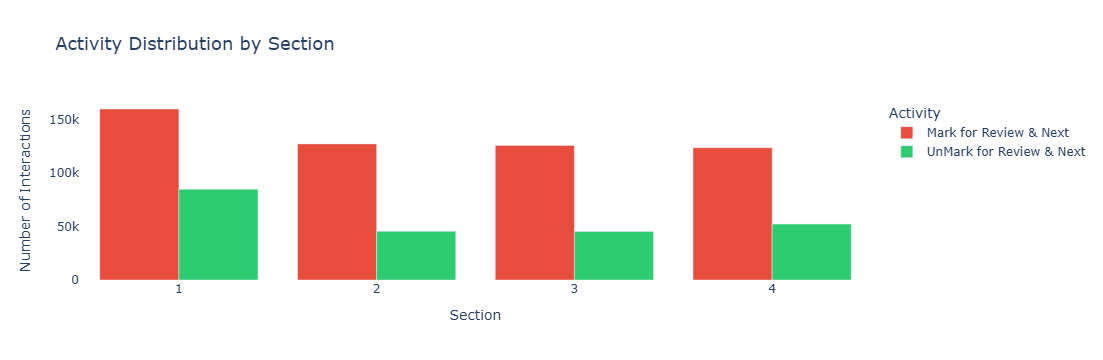

In [18]:
import plotly.express as px

df_section = df_filtered.groupby(['question_section', 'activity']).size().reset_index(name='count')

fig = px.bar(
    df_section,
    x='question_section',
    y='count',
    color='activity',
    barmode='group',
    title='Activity Distribution by Section',
    labels={'question_section': 'Section', 'count': 'Number of Interactions', 'activity': 'Activity'},
    color_discrete_map={
        'Mark for Review & Next': '#E74C3C',
        'UnMark for Review & Next': '#2ECC71'
    }
)

fig.update_layout(
    xaxis=dict(tickmode='linear'),
    plot_bgcolor='white',
    title_font_size=18
)

fig.show()

### Insight: Section 1 had the highest candidate interactions overall
- Section 1 recorded the highest number of both "Mark for Review & Next" (158k) and "UnMark for Review & Next" (84k) interactions.
- The UnMark-to-Mark ratio is also highest in Section 1, indicating that candidates revisited flagged questions more frequently in this section.
- Sections 2, 3, and 4 show very similar interaction volumes, suggesting comparable levels of engagement across these sections.
- Overall, Section 1 stands out as the section where candidates interacted most with the review functionality.

## Analysis 2: Hourly Activity Pattern

**Question:** When were candidates most active during the exam day?

This reveals exam pacing — did candidates rush at the end? 
Were there peak stress hours?

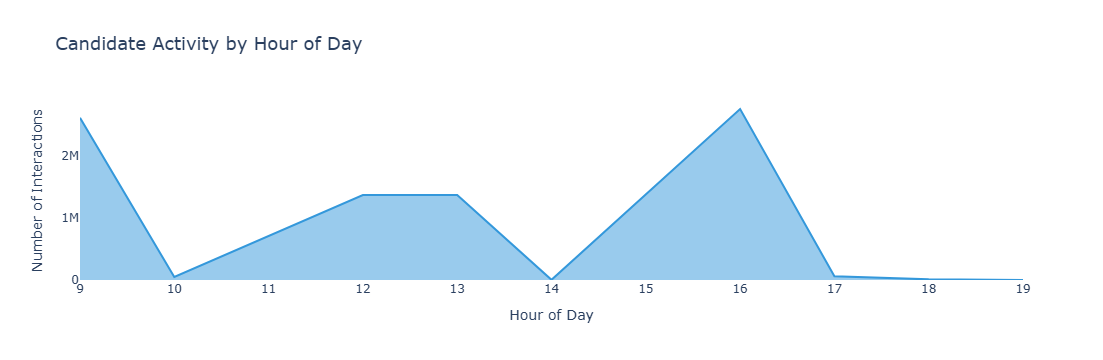

In [20]:
df_hourly = df.groupby('hour').size().reset_index(name='count')

fig = px.area(
    df_hourly,
    x='hour',
    y='count',
    title='Candidate Activity by Hour of Day',
    labels={'hour': 'Hour of Day', 'count': 'Number of Interactions'},
    color_discrete_sequence=['#3498DB']
)

fig.update_layout(
    plot_bgcolor='white',
    title_font_size=18,
    xaxis=dict(tickmode='linear', dtick=1)
)

fig.show()

### Insight: Data reveals Multiple Exam Slots
- The sharp drops at **10:00** and **14:00** are not natural — 
  candidates don't all pause simultaneously
- This pattern strongly suggests **at least 2-3 exam batches** 
  starting at different times (likely 9AM, 11AM, 3PM slots)
- The **peak at 4 PM (258k interactions)** represents the highest 
  simultaneous activity — likely the largest batch mid-exam
- Activity after 17:00 drops sharply as batches conclude
- This is a critical data characteristic that affects 
  any time-based analysis — time should be treated relative 
  to each candidate's start, not absolute clock time

## Analysis 3: Language Preference by Section

**Question:** Do candidates prefer English or Hindi across different sections?

This reveals whether language preference shifts based on subject difficulty —
candidates may switch to their native language for harder sections.

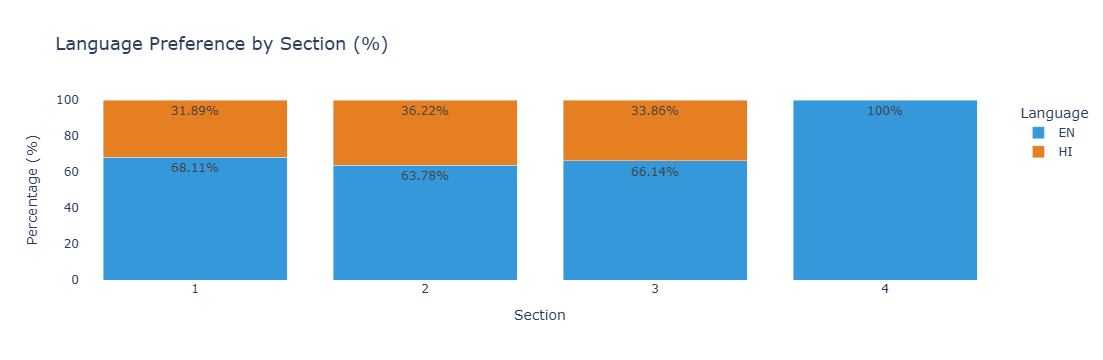

In [14]:
df_lang = df.groupby(['question_section', 'question_language']).size().reset_index(name='count')
df_lang['pct'] = df_lang.groupby('question_section')['count'].transform(lambda x: round(x / x.sum() * 100, 2))

fig = px.bar(
    df_lang,
    x='question_section',
    y='pct',
    color='question_language',
    barmode='stack',
    title='Language Preference by Section (%)',
    labels={
        'question_section': 'Section',
        'pct': 'Percentage (%)',
        'question_language': 'Language'
    },
    color_discrete_map={
        'EN': '#3498DB',
        'HI': '#E67E22'
    },
    text='pct'
)

fig.update_traces(texttemplate='%{text}%', textposition='inside')
fig.update_layout(
    plot_bgcolor='white',
    title_font_size=18,
    xaxis=dict(tickmode='linear'),
    yaxis=dict(range=[0, 100])
)

fig.show()

### Insight: Section 4 was English-Only
- Sections 1, 2, 3 show a **consistent split: ~69% English, ~31% Hindi**
- This consistency suggests language preference is a **candidate-level 
  choice**, not section-dependent
- **Section 4 is 100% English** — this was likely an English-only 
  section with no bilingual option available
- ~31% of candidates attempted in Hindi across sections — 
  a significant minority that the exam platform must support effectively

## Analysis 4: Response Distribution (A/B/C/D)

**Question:** How are candidates distributed across answer choices?

In a fair exam, responses should be roughly equally distributed.
Any strong bias toward one option could indicate guessing patterns
or question design issues.

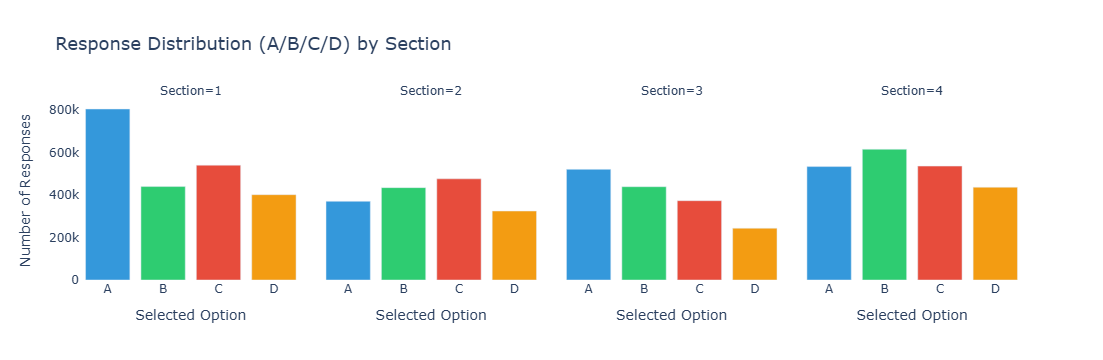

In [15]:
df_resp = df_raw[
    (df_raw['question_response'].notna()) &
    (df_raw['question_response'] != '') &
    (df_raw['question_response'] != 'No Response')
].copy()

df_resp_grouped = df_resp.groupby(
    ['question_section', 'question_response']
).size().reset_index(name='count')

fig = px.bar(
    df_resp_grouped,
    x='question_response',
    y='count',
    color='question_response',
    facet_col='question_section',
    title='Response Distribution (A/B/C/D) by Section',
    labels={
        'question_response': 'Selected Option',
        'count': 'Number of Responses',
        'question_section': 'Section'
    },
    color_discrete_map={
        'A': '#3498DB',
        'B': '#2ECC71',
        'C': '#E74C3C',
        'D': '#F39C12'
    }
)

fig.update_layout(
    plot_bgcolor='white',
    title_font_size=18,
    showlegend=False
)

fig.show()

### Insight: Section 1 shows strong Option A bias — possible guessing pattern
- **Section 1** shows a massive spike for Option A (~804k) vs B/C/D — 
  highly unnatural distribution suggesting candidates **defaulted to A** 
  when unsure, a classic guessing pattern
- **Sections 2, 3, 4** are far more evenly distributed — candidates 
  were more deliberate in later sections
- **Option D is consistently lowest** across all sections — 
  candidates tend to avoid the last option when guessing
- **Section 3** has the lowest Option D count (~240k) — 
  most skewed away from D of all sections

## Analysis 5: Review Behaviour — Mark vs UnMark Ratio

**Question:** Did candidates who flagged questions actually come back to resolve them?

A high UnMark rate means candidates were engaged and revisiting questions.
A low UnMark rate means candidates flagged and abandoned — panic flagging behaviour.